# FTIR Group Talk Draft: Multi-Site BC Storyboard

**Working date:** April 8, 2026  
**Source meeting:** April 1, 2026 with Emma  
**Near-term deadline:** FTIR group talk targeted for **Wednesday, April 15, 2026**

## What This Notebook Is For

This notebook turns the April 1 discussion into a concrete talk and paper storyboard.
It is not a full methods dump. The goal is to support the FTIR group talk with a cleaner narrative:

1. Start from the most informative cross-site figure.
2. Use EC comparisons to interpret what that figure means.
3. Keep AERONET in its own section.
4. Show only a small number of explanatory tests that were tried and ruled out.
5. End with the remaining data-quality questions and the one-week action list.


## Recommended Story Order

### Talk framing

- **Lead with HIPS vs aethalometer across all four sites.** This is the clearest entry point for the paper story.
- **Then show how each optical method compares to FTIR EC.** This tells the audience what the optical methods are and are not capturing.
- **Move AERONET later.** Use it as supporting evidence, not as the opening logic of the talk.
- **Keep only two rule-out analyses in the main talk.** Emma explicitly suggested seasonality and iron.
- **Use the high-resolution aethalometer section as a diagnostic/limitations section.** The point is to show what the MicroAeth data can still be used for, not to frame the story as "the instrument is broken."

### Candidate paper angle

The meeting leaned toward a paper on **aethalometer performance across low- and high-concentration sites**, with HIPS and FTIR EC as supporting comparisons. That angle stays constructive and is more novel than a single-site anomaly paper.


In [1]:
from pathlib import Path
import pandas as pd

BASE = Path.cwd()
SUMMARY_CSV = BASE / "output/group_talk_apr2026/crossplot_summary_group_talk.csv"
summary = pd.read_csv(SUMMARY_CSV)
summary


,plot,site,n,r2,slope,intercept
0,HIPS BC vs FTIR EC,Beijing,144,0.663,0.603,0.539
1,HIPS BC vs FTIR EC,Delhi,58,0.789,0.384,2.354
2,HIPS BC vs FTIR EC,JPL/Pasadena,62,0.261,0.653,0.172
3,HIPS BC vs FTIR EC,Addis Ababa,190,0.764,0.402,2.832
4,Aeth IR BCc vs FTIR EC,Beijing,58,0.509,0.551,0.409
5,Aeth IR BCc vs FTIR EC,Delhi,23,0.547,0.943,2.301
6,Aeth IR BCc vs FTIR EC,JPL/Pasadena,41,0.081,0.515,0.433
7,Aeth IR BCc vs FTIR EC,Addis Ababa,173,0.868,1.404,0.572
8,HIPS BC vs Aeth IR BCc,Beijing,58,0.754,0.779,0.509
9,HIPS BC vs Aeth IR BCc,Delhi,23,0.915,0.484,2.057


## Figure 1: Core Cross-Site Story

![Cross-site core comparisons](output/group_talk_apr2026/crossplots_all_sites_group_talk.png)

### What this figure should say in the talk

- The **HIPS vs aethalometer panel** is the cleanest way to open the story because it compares two absorption-based methods directly across all four sites.
- **Addis Ababa is the clearest anomaly**: the relationship is still tight (`R² ≈ 0.78`) but the slope is very compressed (`~0.27`) and the intercept is large (`~2.84 µg/m³`).
- **Delhi is the useful high-concentration comparison site**: despite less data, it keeps a strong linear relationship with HIPS vs aethalometer (`R² ≈ 0.92`) and a much more interpretable slope than Addis.
- **Beijing and JPL/Pasadena remain low-concentration comparison sites**. They help define the lower-concentration regime, even when their regression details differ.
- The key claim is **not** that one instrument is simply bad. The stronger claim is that **site context matters**, and Addis behaves differently from the other sites in a way that is not yet explained.

### Cross-plot summary table

| plot                   | site         |   n |    r2 |   slope |   intercept |
|:-----------------------|:-------------|----:|------:|--------:|------------:|
| HIPS BC vs FTIR EC     | Beijing      | 144 | 0.663 |   0.603 |       0.539 |
| HIPS BC vs FTIR EC     | Delhi        |  58 | 0.789 |   0.384 |       2.354 |
| HIPS BC vs FTIR EC     | JPL/Pasadena |  62 | 0.261 |   0.653 |       0.172 |
| HIPS BC vs FTIR EC     | Addis Ababa  | 190 | 0.764 |   0.402 |       2.832 |
| Aeth IR BCc vs FTIR EC | Beijing      |  58 | 0.509 |   0.551 |       0.409 |
| Aeth IR BCc vs FTIR EC | Delhi        |  23 | 0.547 |   0.943 |       2.301 |
| Aeth IR BCc vs FTIR EC | JPL/Pasadena |  41 | 0.081 |   0.515 |       0.433 |
| Aeth IR BCc vs FTIR EC | Addis Ababa  | 173 | 0.868 |   1.404 |       0.572 |
| HIPS BC vs Aeth IR BCc | Beijing      |  58 | 0.754 |   0.779 |       0.509 |
| HIPS BC vs Aeth IR BCc | Delhi        |  23 | 0.915 |   0.484 |       2.057 |
| HIPS BC vs Aeth IR BCc | JPL/Pasadena |  41 | 0.72  |   0.573 |       0.168 |
| HIPS BC vs Aeth IR BCc | Addis Ababa  | 173 | 0.778 |   0.266 |       2.835 |


## Figure 1b: Separate Panels (white background, manual exclusions applied)

The panels below reproduce the three core cross-plots **individually** (not as a collage) so each can be shown on its own slide. All three apply the same manual exclusion set as `cross_plots_and_distributions.ipynb` and the `outliers.py` registry:

- EC below MDL (0.5 µg/m³) or negative EC
- Beijing: aethalometer > 4 µg/m³
- Delhi: aeth > 8 with EC < 3 (mismatch), and EC > 20 µg/m³ (INDH-0172-4 extreme outlier)
- JPL/Pasadena: aeth > 1.7 OR EC > 1.0 µg/m³
- Addis Ababa: no manual date-based exclusions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# White background everywhere — no seaborn darkgrid
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'savefig.facecolor':'white',
    'axes.edgecolor':   'black',
    'axes.grid':        False,
    'font.size':        11,
    'figure.dpi':       120,
})

BASE = Path.cwd()
FILTER_PATH = BASE / 'Filter Data' / 'unified_filter_dataset.pkl'
PROCESSED_DIR = BASE / 'processed_sites'
OUT_DIR = BASE / 'output' / 'group_talk_apr2026'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SITE_MAP = {'CHTS': 'Beijing', 'ETAD': 'Addis_Ababa', 'INDH': 'Delhi', 'USPA': 'JPL'}
SITE_LABELS = {'Beijing': 'Beijing', 'Delhi': 'Delhi', 'JPL': 'JPL/Pasadena', 'Addis_Ababa': 'Addis Ababa'}
SITE_COLORS = {'Beijing': '#E74C3C', 'Delhi': '#3498DB', 'JPL': '#2ECC71', 'Addis_Ababa': '#F39C12'}
MAC_VALUE = 10  # m^2/g

# --- Load filter data (wide) ---
df_filter_raw = pd.read_pickle(FILTER_PATH)
df_filter_raw['SampleDate'] = pd.to_datetime(df_filter_raw['SampleDate'])
df_filter_raw['SiteName'] = df_filter_raw['Site'].map(SITE_MAP)

key_params = ['EC_ftir', 'HIPS_Fabs']
df_filt = df_filter_raw[df_filter_raw['Parameter'].isin(key_params)].copy()
filter_wide = df_filt.pivot_table(
    index=['Site', 'SiteName', 'FilterId', 'SampleDate'],
    columns='Parameter', values='Concentration', aggfunc='first',
).reset_index()
filter_wide['HIPS_BC'] = filter_wide['HIPS_Fabs'] / MAC_VALUE
filter_wide['aeth_IR_BCc'] = np.nan

# --- Match 9am aethalometer IR BCc by sample date ---
for site_code, site_name in SITE_MAP.items():
    fpath = PROCESSED_DIR / f'df_{site_name}_9am_resampled.pkl'
    if not fpath.exists():
        continue
    df_aeth = pd.read_pickle(fpath)
    dt_col = df_aeth['datetime_local']
    if len(dt_col.shape) > 1:
        dt_col = dt_col.iloc[:, 0]
    ir_col = df_aeth['IR BCc']
    if len(ir_col.shape) > 1:
        ir_col = ir_col.iloc[:, 0]
    aeth_daily = pd.DataFrame({
        'date': pd.to_datetime(dt_col).dt.date,
        'aeth_IR_BCc': ir_col.values,
    }).dropna()
    if aeth_daily['aeth_IR_BCc'].median() > 100:
        aeth_daily['aeth_IR_BCc'] /= 1000.0
    mask = filter_wide['SiteName'] == site_name
    for idx in filter_wide[mask].index:
        d = filter_wide.loc[idx, 'SampleDate'].date()
        m = aeth_daily[aeth_daily['date'] == d]
        if len(m):
            filter_wide.loc[idx, 'aeth_IR_BCc'] = m['aeth_IR_BCc'].iloc[0]

# --- Manual exclusions (mirrors outliers.py registry + cross_plots_and_distributions.ipynb) ---
MIN_EC = 0.5
filter_wide['is_excluded'] = False
filter_wide.loc[(filter_wide['EC_ftir'] < MIN_EC) & filter_wide['EC_ftir'].notna(), 'is_excluded'] = True
filter_wide.loc[filter_wide['EC_ftir'].notna() & (filter_wide['EC_ftir'] < 0), 'is_excluded'] = True
filter_wide.loc[(filter_wide['SiteName'] == 'Beijing') & (filter_wide['aeth_IR_BCc'] > 4.0), 'is_excluded'] = True
filter_wide.loc[(filter_wide['SiteName'] == 'Delhi') & (filter_wide['aeth_IR_BCc'] > 8.0) & (filter_wide['EC_ftir'] < 3.0), 'is_excluded'] = True
filter_wide.loc[(filter_wide['SiteName'] == 'Delhi') & (filter_wide['EC_ftir'] > 20.0), 'is_excluded'] = True
filter_wide.loc[(filter_wide['SiteName'] == 'JPL') & ((filter_wide['aeth_IR_BCc'] > 1.7) | (filter_wide['EC_ftir'] > 1.0)), 'is_excluded'] = True

filter_clean = filter_wide[~filter_wide['is_excluded']].copy()
print(f"Total filters: {len(filter_wide)}  |  Excluded: {filter_wide['is_excluded'].sum()}  |  Clean: {len(filter_clean)}")
for site in SITE_MAP.values():
    s = filter_clean[filter_clean['SiteName'] == site]
    print(f"  {SITE_LABELS[site]:13s}: n_EC={s['EC_ftir'].notna().sum():3d}  n_HIPS={s['HIPS_BC'].notna().sum():3d}  n_aeth={s['aeth_IR_BCc'].notna().sum():3d}")

Total filters: 597  |  Excluded: 124  |  Clean: 473
  Beijing      : n_EC=162  n_HIPS=144  n_aeth= 58
  Addis Ababa  : n_EC=190  n_HIPS=190  n_aeth=173
  Delhi        : n_EC= 57  n_HIPS= 57  n_aeth= 23
  JPL/Pasadena : n_EC= 64  n_HIPS= 60  n_aeth= 40


In [3]:
def plot_single_crossplot(data, x_col, y_col, x_label, y_label, title, out_name):
    fig, ax = plt.subplots(figsize=(7.5, 7.5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    for i, site_name in enumerate(['Beijing', 'Delhi', 'JPL', 'Addis_Ababa']):
        s = data[data['SiteName'] == site_name].dropna(subset=[x_col, y_col])
        if len(s) < 3:
            continue
        x, y = s[x_col].values, s[y_col].values
        color = SITE_COLORS[site_name]
        ax.scatter(x, y, alpha=0.55, s=30, color=color, edgecolors='black',
                   linewidth=0.3, label=f'{SITE_LABELS[site_name]} (n={len(s)})')

        if len(s) >= 5:
            slope, intercept, r, p, se = stats.linregress(x, y)
            x_fit = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_fit, slope * x_fit + intercept, '--', color=color, lw=1.8, alpha=0.9)
            ax.text(0.02, 0.98 - i * 0.06,
                    f'{SITE_LABELS[site_name]}: y={slope:.2f}x+{intercept:.2f}, R²={r**2:.2f}',
                    transform=ax.transAxes, fontsize=9, color=color, va='top', fontweight='bold')

    lim = max(data[x_col].max(), data[y_col].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5, label='1:1')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(x_label); ax.set_ylabel(y_label)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right', framealpha=0.95)
    ax.set_aspect('equal')
    for spine in ax.spines.values():
        spine.set_color('black')
    fig.tight_layout()
    fig.savefig(OUT_DIR / out_name, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    return fig

### Panel 1 — HIPS vs Aethalometer IR BCc

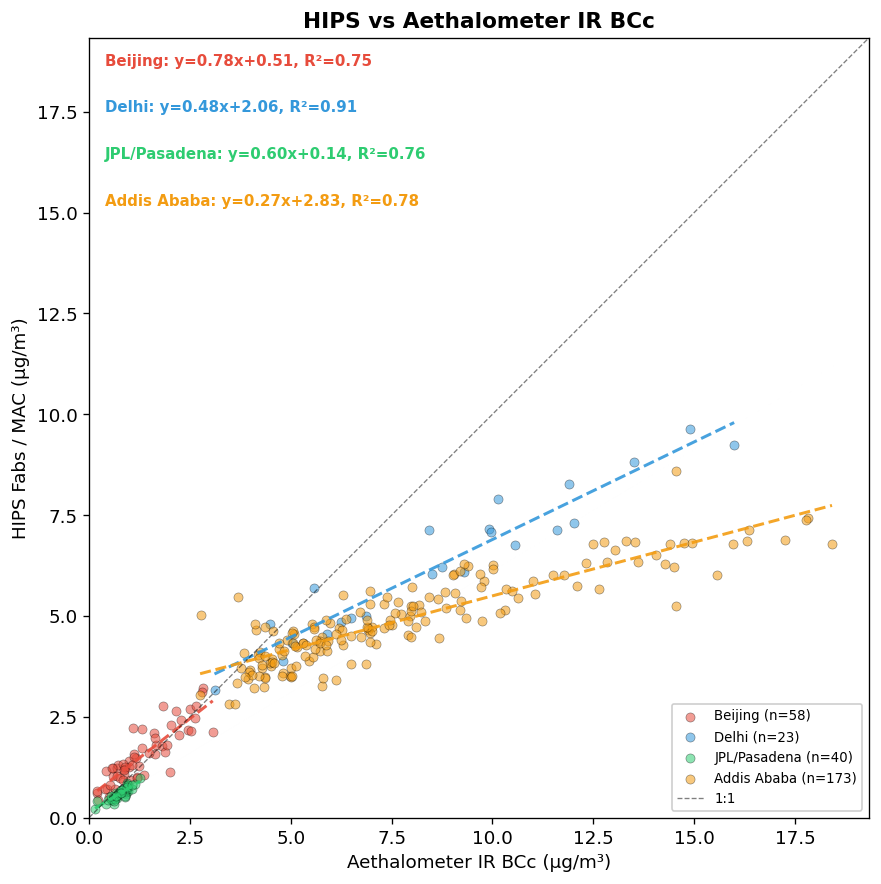

In [4]:
d = filter_clean.dropna(subset=['HIPS_BC', 'aeth_IR_BCc'])
plot_single_crossplot(d, 'aeth_IR_BCc', 'HIPS_BC',
    'Aethalometer IR BCc (µg/m³)', 'HIPS Fabs / MAC (µg/m³)',
    'HIPS vs Aethalometer IR BCc',
    'panel_hips_vs_aeth_separate.png');

### Panel 2 — HIPS vs FTIR EC

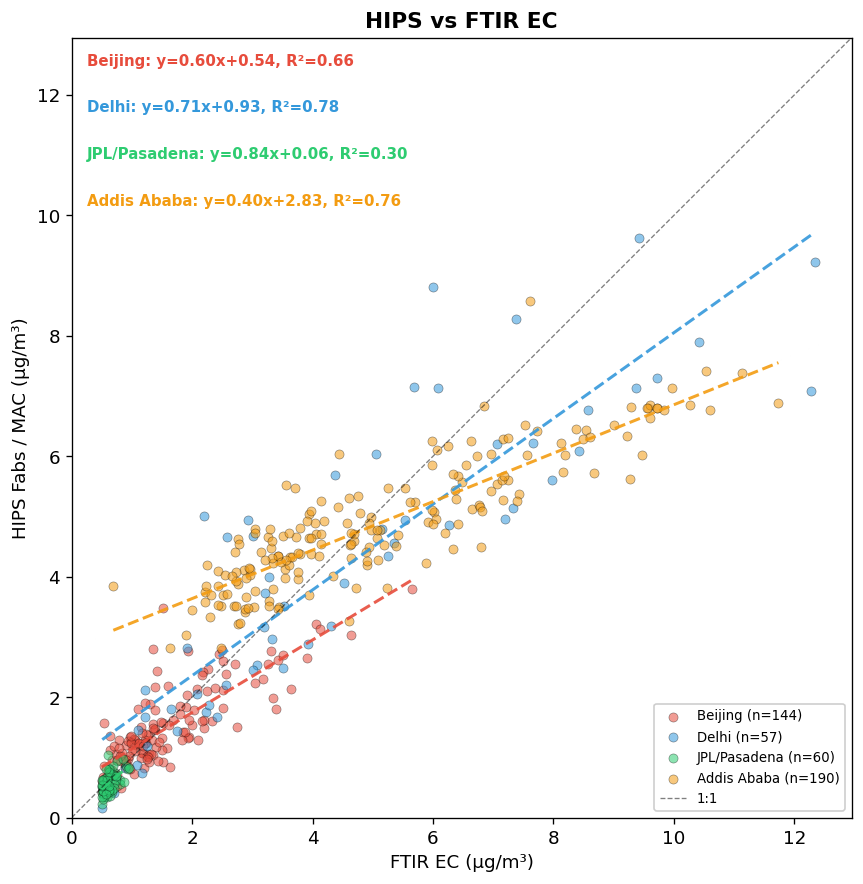

In [5]:
d = filter_clean.dropna(subset=['EC_ftir', 'HIPS_BC'])
plot_single_crossplot(d, 'EC_ftir', 'HIPS_BC',
    'FTIR EC (µg/m³)', 'HIPS Fabs / MAC (µg/m³)',
    'HIPS vs FTIR EC',
    'panel_hips_vs_ftir_separate.png');

### Panel 3 — Aethalometer IR BCc vs FTIR EC

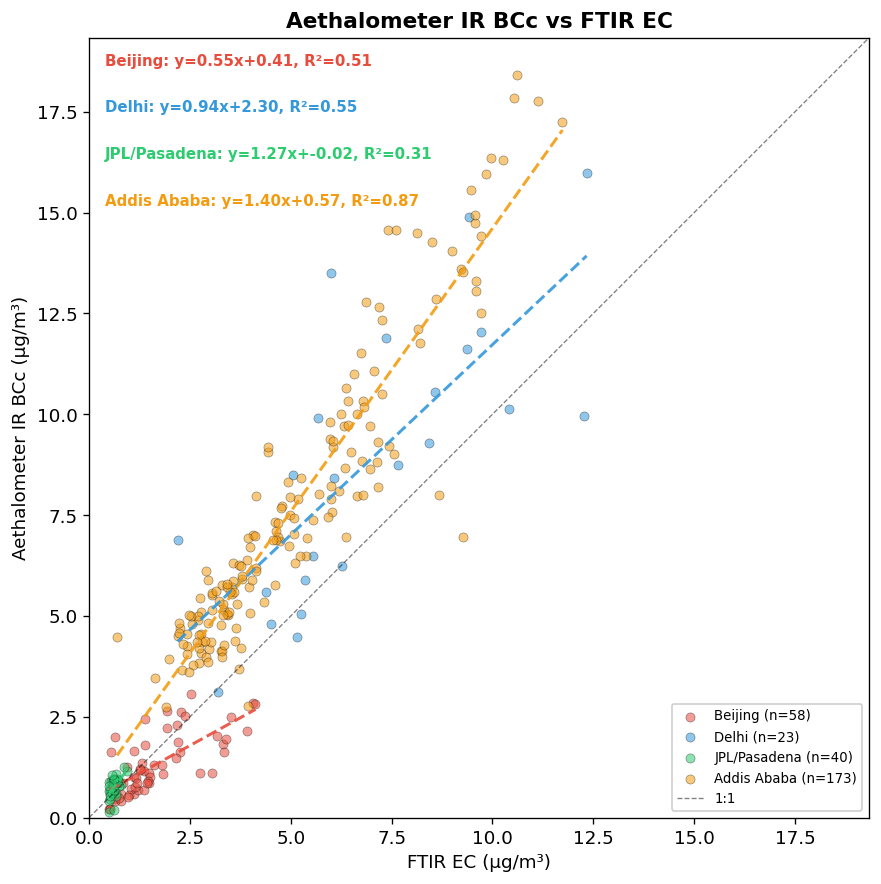

In [6]:
d = filter_clean.dropna(subset=['EC_ftir', 'aeth_IR_BCc'])
plot_single_crossplot(d, 'EC_ftir', 'aeth_IR_BCc',
    'FTIR EC (µg/m³)', 'Aethalometer IR BCc (µg/m³)',
    'Aethalometer IR BCc vs FTIR EC',
    'panel_aeth_vs_ftir_separate.png');

## Figure 2: What the FTIR EC Comparisons Add

The other two panels in Figure 1 should be introduced immediately after the HIPS vs aethalometer panel.

### HIPS vs FTIR EC

- This is where the **Addis intercept and compressed range** remain most obvious.
- Delhi still behaves as a useful high-concentration comparison, even though the sample count is smaller.
- The point of this panel is to show that the Addis issue is **not only an aethalometer story**.

### Aethalometer vs FTIR EC

- Addis does **not** look anomalous in the same way here.
- That contrast is important because it means the Addis anomaly is not a simple "all optical methods fail at Addis" result.
- This panel is the reason Emma suggested that the final paper framing may be stronger if it starts from **aethalometer performance across sites** and then uses FTIR/HIPS to interpret the differences.


## Figure 3: Keep Only Two Main Explanatory Tests

Emma's guidance was to keep the talk focused and only show one or two tests of hypotheses that did **not** explain the anomaly. The cleanest pair is **seasonality** and **iron**.

### Iron / dust test

![Iron analysis](../../notebooks/analysis/output/plots/pub_figures/fig08_hips_ftir_iron.png)

- Splitting by iron did **not** separate the regressions in a way that explains the Addis anomaly.
- This supports the meeting conclusion that iron or dust interference, at least in the way it was tested here, does **not** explain the intercept/compressed-range problem.

### Seasonal test

![Seasonal HIPS vs FTIR](../../notebooks/analysis/output/plots/pub_figures/fig10_seasonal_hips_ftir.png)

- Seasonal splitting does **not** remove the Addis problem.
- The anomaly appears **year-round**, which is a stronger and cleaner statement than showing a long list of failed diagnostics.
- This is one of the most important talk simplifications: keep the rule-out story short and defensible.


## Figure 3b: Iron Median Split — All Four Sites

Reproduces the "Iron Median Split: HIPS vs FTIR EC" slide as a 2×2 grid (Beijing, Delhi, JPL/Pasadena, Addis Ababa) and also as **four individual single-site panels** for slide reuse. Uses the same manual exclusions as Figure 1b, plus a per-site **median-iron split** into low-Fe vs high-Fe groups with separate regression lines.

**Talk point:** Iron does not cleanly separate the Addis regressions — the offset is there in both low-Fe and high-Fe groups.

In [7]:
# --- Merge iron (ChemSpec_Iron_PM2.5) into the clean filter dataset ---
# Iron FilterIds (e.g. CHTS-0018) don't carry the -N suffix that EC/HIPS FilterIds do
# (e.g. CHTS-0658-1), so merge on Site + SampleDate rather than FilterId.
# Iron concentration is reported in ng/m³; convert to µg/m³ for plotting.
iron_raw = df_filter_raw[df_filter_raw['Parameter'] == 'ChemSpec_Iron_PM2.5'].copy()
iron_raw['iron'] = iron_raw['Concentration'] / 1000.0
iron_wide = iron_raw.groupby(['Site', 'SampleDate'], as_index=False)['iron'].first()

filter_iron = filter_clean.merge(
    iron_wide[['Site', 'SampleDate', 'iron']],
    on=['Site', 'SampleDate'], how='left',
)

print("Iron merge summary:")
for site in ['Beijing', 'Delhi', 'JPL', 'Addis_Ababa']:
    s = filter_iron[filter_iron['SiteName'] == site]
    n_triple = s.dropna(subset=['EC_ftir', 'HIPS_BC', 'iron']).shape[0]
    med_fe = s['iron'].median()
    print(f"  {SITE_LABELS[site]:13s}: n(EC+HIPS+Fe)={n_triple:3d}  median_Fe={med_fe:.3f} µg/m³")

Iron merge summary:
  Beijing      : n(EC+HIPS+Fe)=133  median_Fe=0.349 µg/m³
  Delhi        : n(EC+HIPS+Fe)= 26  median_Fe=0.663 µg/m³
  JPL/Pasadena : n(EC+HIPS+Fe)= 60  median_Fe=0.095 µg/m³
  Addis Ababa  : n(EC+HIPS+Fe)=189  median_Fe=0.289 µg/m³


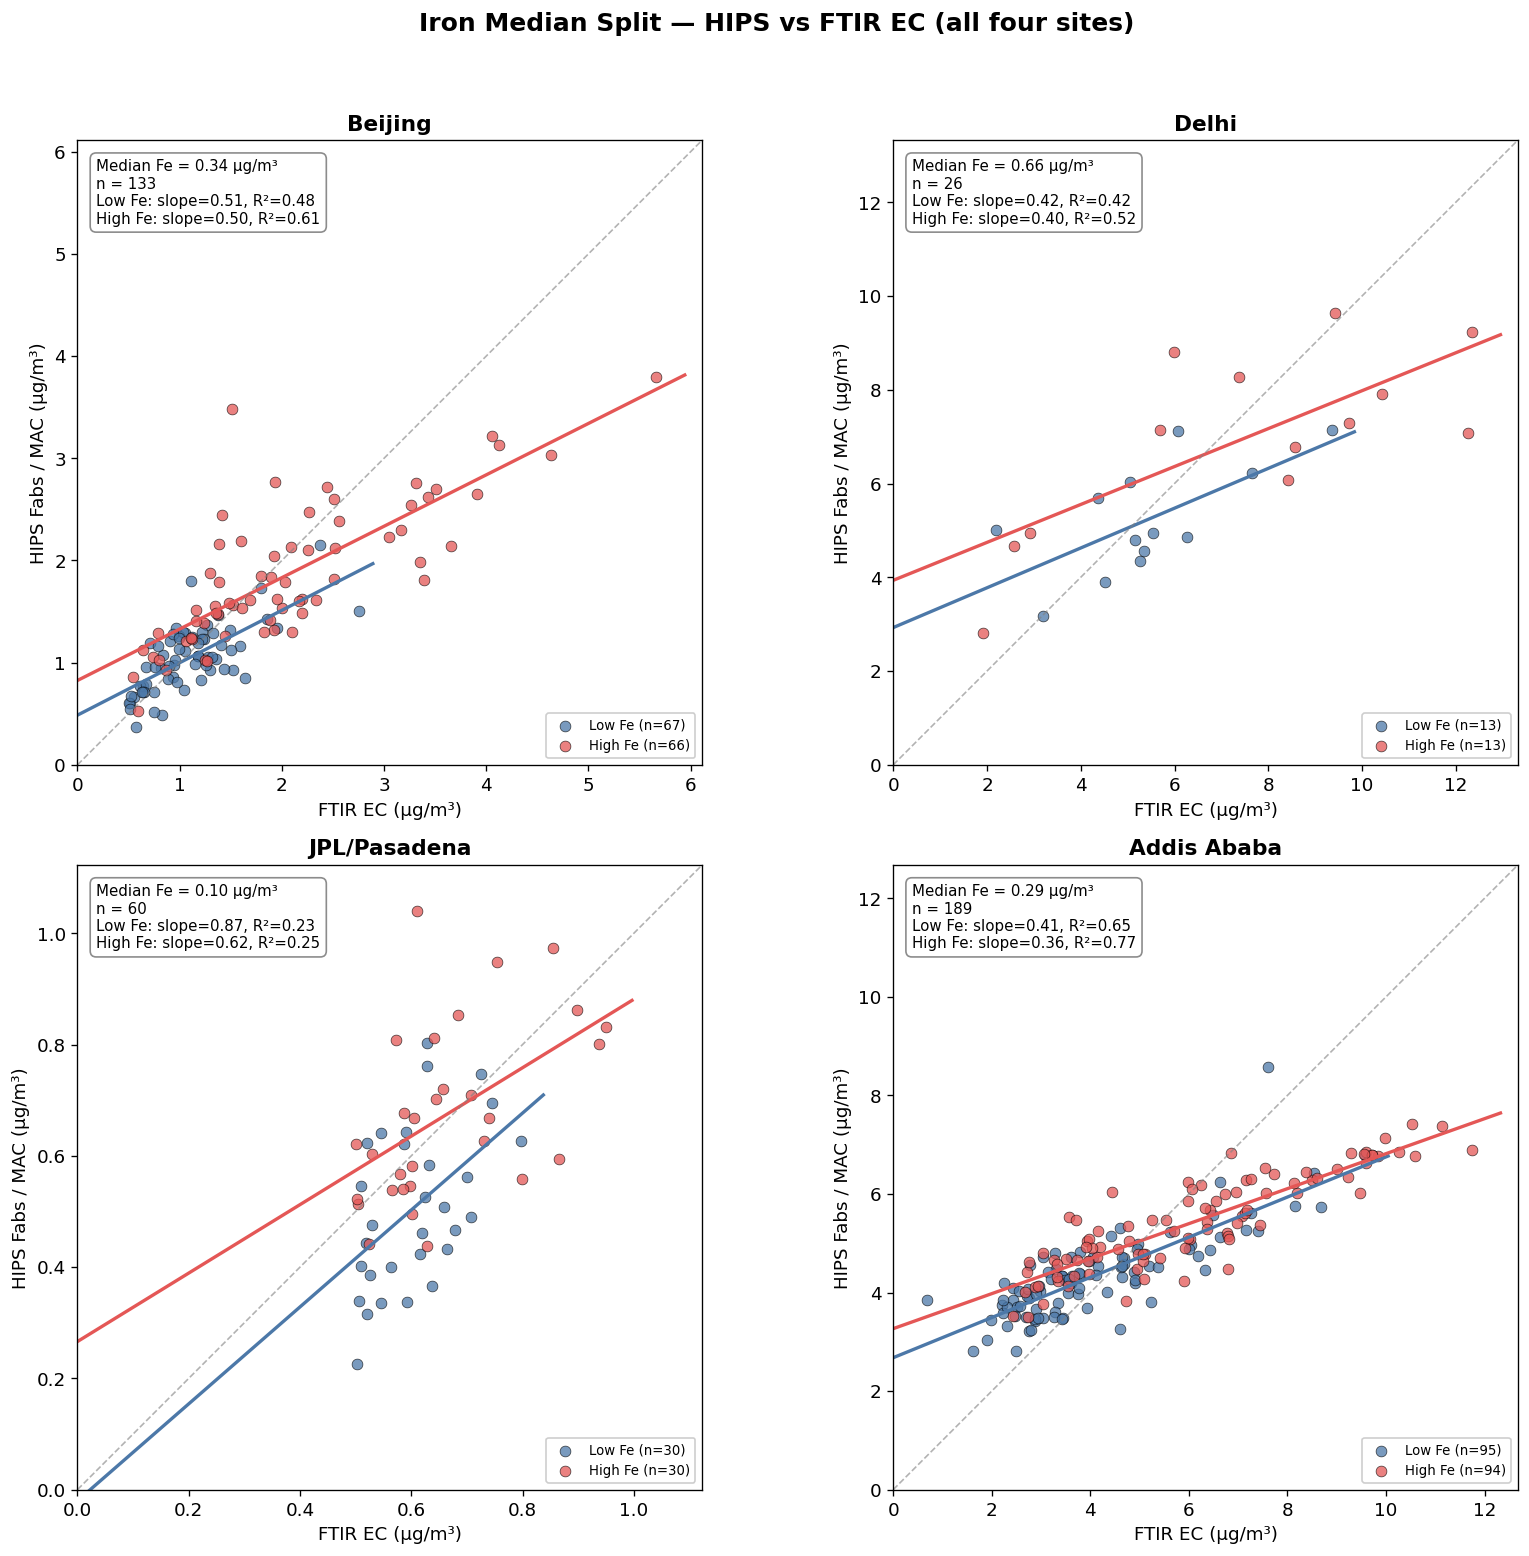

,site,group,n,slope,intercept,r_squared,median_iron
0,Beijing,Low Fe,67,0.513,0.487,0.477,0.342
1,Beijing,High Fe,66,0.503,0.826,0.609,0.342
2,Delhi,Low Fe,13,0.424,2.927,0.420,0.663
3,Delhi,High Fe,13,0.404,3.935,0.525,0.663
4,JPL/Pasadena,Low Fe,30,0.871,-0.020,0.233,0.095
5,JPL/Pasadena,High Fe,30,0.615,0.266,0.255,0.095
6,Addis Ababa,Low Fe,95,0.407,2.677,0.650,0.289
7,Addis Ababa,High Fe,94,0.355,3.267,0.768,0.289


In [8]:
# --- 2x2 grid: iron median split, HIPS vs FTIR EC ---
GROUP_COLORS = {'Low Fe': '#4C78A8', 'High Fe': '#E45756'}

def plot_iron_panel(ax, site_name):
    s = filter_iron[filter_iron['SiteName'] == site_name].dropna(subset=['EC_ftir', 'HIPS_BC', 'iron'])
    ax.set_facecolor('white')
    ax.set_title(SITE_LABELS[site_name], fontsize=13, fontweight='bold')
    ax.set_xlabel('FTIR EC (µg/m³)')
    ax.set_ylabel('HIPS Fabs / MAC (µg/m³)')

    if len(s) < 6:
        ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes, ha='center', va='center')
        return None

    thr = s['iron'].median()
    s = s.copy()
    s['iron_group'] = np.where(s['iron'] <= thr, 'Low Fe', 'High Fe')
    notes = [f'Median Fe = {thr:.2f} µg/m³', f'n = {len(s)}']

    rows = []
    for grp_name in ['Low Fe', 'High Fe']:
        g = s[s['iron_group'] == grp_name]
        if len(g) < 3: continue
        color = GROUP_COLORS[grp_name]
        ax.scatter(g['EC_ftir'], g['HIPS_BC'], color=color, alpha=0.75, s=42,
                   edgecolors='black', linewidth=0.4, label=f'{grp_name} (n={len(g)})')
        if len(g) >= 5:
            slope, intercept, r, p, se = stats.linregress(g['EC_ftir'], g['HIPS_BC'])
            xf = np.linspace(0, g['EC_ftir'].max() * 1.05, 100)
            ax.plot(xf, slope * xf + intercept, color=color, linewidth=2)
            notes.append(f'{grp_name}: slope={slope:.2f}, R²={r**2:.2f}')
            rows.append({'site': SITE_LABELS[site_name], 'group': grp_name, 'n': len(g),
                         'slope': slope, 'intercept': intercept, 'r_squared': r**2,
                         'median_iron': thr})

    lim = max(s['EC_ftir'].max(), s['HIPS_BC'].max()) * 1.08
    ax.plot([0, lim], [0, lim], '--', color='gray', linewidth=1.0, alpha=0.6)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal', adjustable='box')
    ax.text(0.03, 0.97, '\n'.join(notes), transform=ax.transAxes, va='top', ha='left',
            fontsize=9, bbox={'boxstyle': 'round,pad=0.4', 'facecolor': 'white', 'alpha': 0.9,
                              'edgecolor': 'gray'})
    ax.legend(fontsize=8, loc='lower right', framealpha=0.95)
    for spine in ax.spines.values(): spine.set_color('black')
    return rows

fig, axes = plt.subplots(2, 2, figsize=(14, 13), facecolor='white')
summary = []
for ax, site in zip(axes.flatten(), ['Beijing', 'Delhi', 'JPL', 'Addis_Ababa']):
    r = plot_iron_panel(ax, site)
    if r: summary.extend(r)

fig.suptitle('Iron Median Split — HIPS vs FTIR EC (all four sites)', fontsize=15, fontweight='bold', y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUT_DIR / 'iron_split_all_sites_hips_vs_ftir_white.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

iron_summary = pd.DataFrame(summary)
iron_summary.to_csv(OUT_DIR / 'iron_split_all_sites_hips_vs_ftir_white_summary.csv', index=False)
iron_summary.round(3)

### Individual per-site panels

Same iron median split, rendered **one site per figure** so each can be dropped into its own slide.

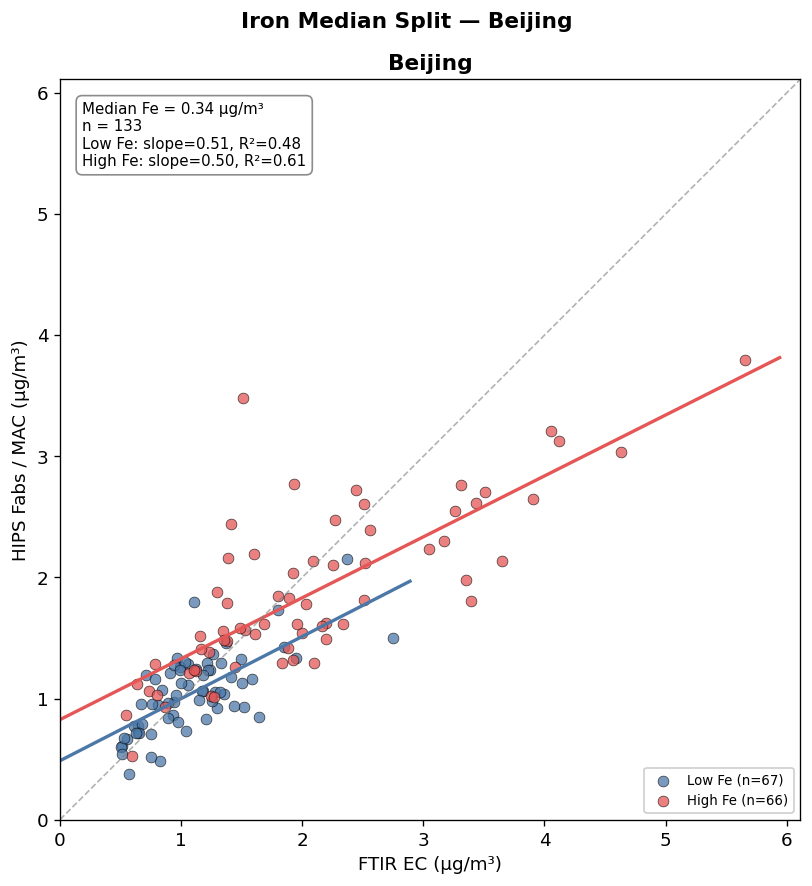

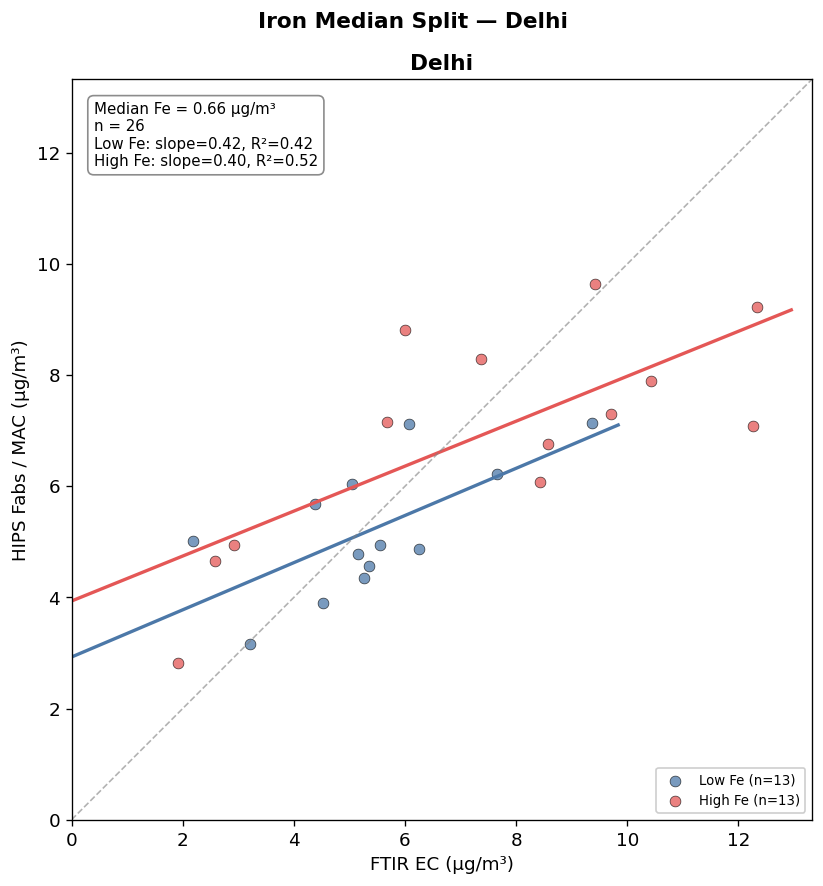

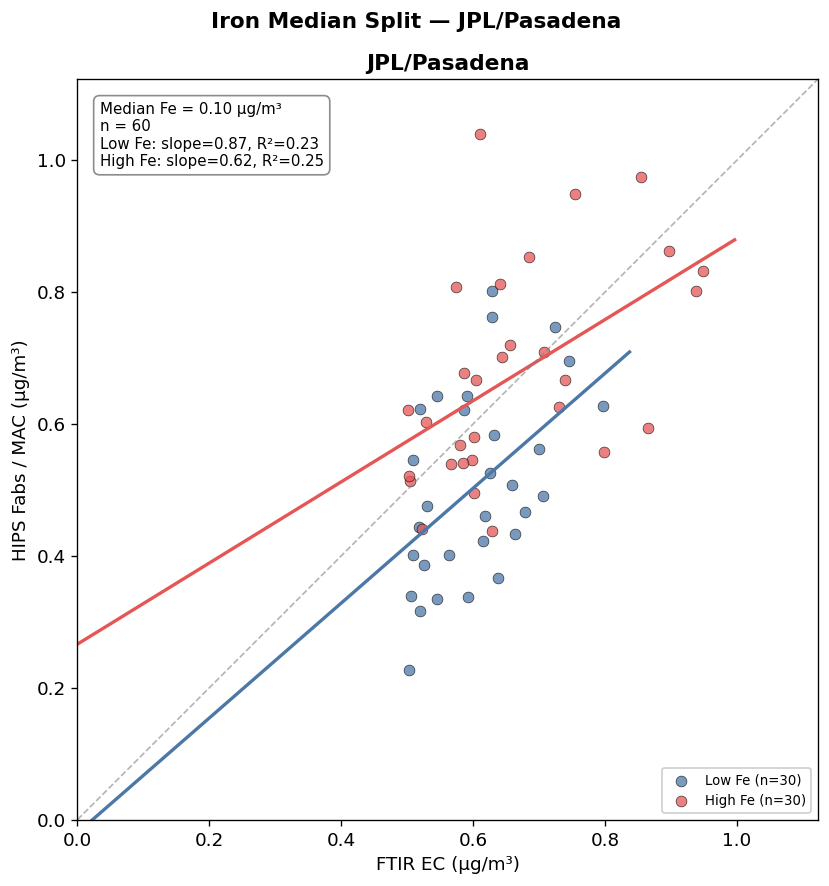

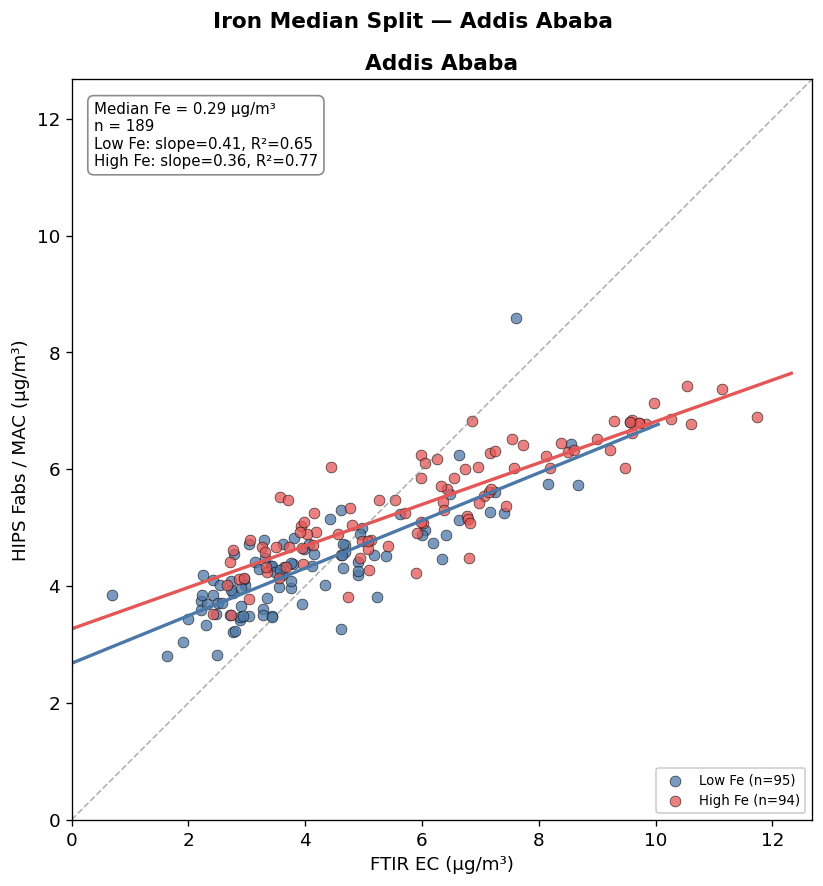

In [9]:
for site in ['Beijing', 'Delhi', 'JPL', 'Addis_Ababa']:
    fig, ax = plt.subplots(figsize=(7.5, 7.5), facecolor='white')
    plot_iron_panel(ax, site)
    fig.suptitle(f'Iron Median Split — {SITE_LABELS[site]}', fontsize=13, fontweight='bold')
    fig.tight_layout()
    out_name = f'iron_split_{site.lower()}_hips_vs_ftir.png'
    fig.savefig(OUT_DIR / out_name, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()

## Figure 4: AERONET Belongs in Its Own Section

![HIPS/FTIR ratio vs AOD](../../notebooks/analysis/output/plots/pub_figures/fig07_hips_ftir_vs_aod.png)

### How to use the AERONET material in this talk

- Do **not** open with AERONET.
- Put all AERONET slides into one dedicated section after the core cross-site method comparisons.
- Show the **non-seasonal** AERONET result first, then any seasonal breakdown.
- The value of this section is supporting context: it helps describe why columnar conditions may matter, but it does **not** currently explain the Addis anomaly by itself.

### Slide cleanup captured from the meeting

- Fix the mislabeled x-axis on the old slide 7A.
- Fix the figure label where HIPS appeared twice and one label should have been FTIR.
- Reorder the AERONET material so the broad result comes before the seasonal refinement.


## Figure 5: High-Resolution Aethalometer Diagnostics

![Diurnal all wavelengths](../../notebooks/analysis/output/plots/diurnal_pub/slide05_diurnal_all_wavelengths.png)

![Wavelength ratios](../../notebooks/analysis/output/plots/diurnal_pub/slide06_wavelength_ratios.png)

### Why this section matters

- The high-resolution data is now available and cleaned, so it can be used as a real diagnostic section in the talk.
- **Beijing and Delhi show wavelength separation**, which supports using spectral behavior for source interpretation.
- **Addis/"Otis" shows excessive wavelength stacking**, especially once the corrected channels are used. That is a data-quality concern worth discussing with Sina.
- Addis also appears **artificially smooth** compared with the other sites. That was explicitly flagged in the meeting as likely non-physical.
- The talk framing here should stay constructive: this section defines **what the MicroAeth data can still be used for**, and where caution is needed.


## Questions for the Follow-Up Meetings

### For Sina

- Why are most Addis wavelengths nearly stacked once the corrected columns are used?
- What exact correction pipeline was applied to the Addis MA350 data before delivery?
- Is the strong Addis smoothing expected from the vendor/data provider workflow, or is it a processing artifact?
- Can the large evening Kiremt peak be checked against boundary-layer information and any co-located PM data?

### For Warren

- Does anything in the HIPS methodology explain the persistent Addis intercept and compressed HIPS range relative to FTIR EC?
- Are there known HIPS behaviors at high-concentration or dust-influenced sites that could resemble Addis without implying a simple instrument failure?


## One-Week Action List for the April 15 Talk

### Slide deck edits

- [ ] Rebuild the deck around the story order above, not around every analysis that has been attempted.
- [ ] Start with the HIPS vs aethalometer figure and add interpretation bullets directly on the slide.
- [ ] Follow with the EC comparison slides.
- [ ] Move all AERONET slides into one dedicated section.
- [ ] Show non-seasonal AERONET first, then seasonal breakdown.

### Figure fixes and additions

- [ ] Fix the mislabeled axis on the old slide 7A.
- [ ] Fix the duplicated HIPS label so FTIR is labeled correctly.
- [ ] Prepare an iron analysis comparison for all four sites if the matched data exists.
- [ ] Prepare a seasonal comparison across all four sites.

### Meeting follow-ups

- [ ] Ask Emma for the Addis boundary-layer-height plot if it is not already in the working folder.
- [ ] Schedule the Sina walkthrough focused on Addis aethalometer data quality.
- [ ] Reconnect with Warren on the HIPS-vs-FTIR interpretation.

### Claims to keep stable in the talk

- Addis Ababa is the clearest site-specific anomaly.
- The anomaly is year-round and remains unexplained by the leading tests shown here.
- The constructive goal is to define where the MicroAeth data is useful across sites, and where interpretation should be limited.


## Working Slide List for the New Weekly Deck

1. **Title / why this talk exists**
2. **Core cross-site figure: HIPS vs aethalometer, with interpretation bullets**
3. **Support: HIPS vs FTIR EC and aethalometer vs FTIR EC**
4. **Rule-out tests: seasonality and iron**
5. **AERONET section: broad result first**
6. **High-resolution aethalometer diagnostics across sites**
7. **Addis-specific data-quality questions for Sina**
8. **Next steps before April 15, 2026**

That should be enough for a weekly group-talk draft without collapsing into a long methods review.
